In [1]:
import pandas as pd
import numpy as np

In [22]:
df = pd.read_excel("../data/Online Retail.xlsx")

In [23]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [24]:
df.shape

(541909, 8)

In [25]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [27]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [29]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [30]:
df.isnull().mean() * 100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [31]:
df_clean = df.dropna(subset=["CustomerID"]).copy()

In [32]:
df_clean.shape

(406829, 8)

In [33]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [34]:
df_clean[df_clean["Quantity"] < 0].shape

(8905, 8)

In [35]:
df_clean[df_clean["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [36]:
df_clean["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(8905)

In [37]:
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0) &
    (~df_clean["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

In [38]:
df_clean.shape

(397884, 8)

In [40]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [42]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,179.331775,NaN,22.097877,1713.141560


In [43]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [44]:
df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [45]:
df_clean["Revenue"].describe()

count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

In [49]:
customer_df = df_clean.groupby("CustomerID").agg(
    total_spend=("Revenue", "sum"),
    number_of_orders=("InvoiceNo", "nunique")
).reset_index()

In [56]:
customer_df.shape

(4338, 4)

In [55]:
customer_df.head()

,CustomerID,total_spend,number_of_orders,average_order_value
0,12346.0,77183.60,1,77183.600000
1,12347.0,4310.00,7,615.714286
2,12348.0,1797.24,4,449.310000
3,12349.0,1757.55,1,1757.550000
4,12350.0,334.40,1,334.400000


In [54]:
customer_df["average_order_value"] = (
    customer_df["total_spend"] / customer_df["number_of_orders"]
)

In [57]:
df_clean["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [58]:
reference_date = df_clean["InvoiceDate"].max()

In [59]:
last_purchase = df_clean.groupby("CustomerID")["InvoiceDate"].max()

In [60]:
recency = (reference_date - last_purchase).dt.days

In [61]:
customer_df["recency_days"] = customer_df["CustomerID"].map(recency)

In [63]:
customer_df.shape

(4338, 5)

In [66]:
customer_df.head()

,CustomerID,total_spend,number_of_orders,average_order_value,recency_days
0,12346.0,77183.60,1,77183.600000,325
1,12347.0,4310.00,7,615.714286,1
2,12348.0,1797.24,4,449.310000,74
3,12349.0,1757.55,1,1757.550000,18
4,12350.0,334.40,1,334.400000,309


In [67]:
customer_df["recency_days"].describe()

count    4338.000000
mean       91.536422
std       100.014169
min         0.000000
25%        17.000000
50%        50.000000
75%       141.000000
max       373.000000
Name: recency_days, dtype: float64

In [68]:
first_purchase = df_clean.groupby("CustomerID")["InvoiceDate"].min()

In [69]:
customer_lifetime_days = (reference_date - first_purchase).dt.days

In [70]:
customer_df["customer_lifetime_days"] = customer_df["CustomerID"].map(customer_lifetime_days)

In [71]:
customer_df["purchase_frequency"] = (
    customer_df["number_of_orders"] /
    (customer_df["customer_lifetime_days"] + 1)
)

In [72]:
customer_df.head()

,CustomerID,total_spend,number_of_orders,average_order_value,recency_days,customer_lifetime_days,purchase_frequency
0,12346.0,77183.60,1,77183.600000,325,325,0.003067
1,12347.0,4310.00,7,615.714286,1,366,0.019074
2,12348.0,1797.24,4,449.310000,74,357,0.011173
3,12349.0,1757.55,1,1757.550000,18,18,0.052632
4,12350.0,334.40,1,334.400000,309,309,0.003226


In [73]:
customer_df.shape

(4338, 7)

In [74]:
unique_products = df_clean.groupby("CustomerID")["StockCode"].nunique()

In [75]:
customer_df["unique_products"] = customer_df["CustomerID"].map(unique_products)

In [76]:
customer_df.head()

,CustomerID,total_spend,number_of_orders,average_order_value,recency_days,customer_lifetime_days,purchase_frequency,unique_products
0,12346.0,77183.60,1,77183.600000,325,325,0.003067,1
1,12347.0,4310.00,7,615.714286,1,366,0.019074,103
2,12348.0,1797.24,4,449.310000,74,357,0.011173,22
3,12349.0,1757.55,1,1757.550000,18,18,0.052632,73
4,12350.0,334.40,1,334.400000,309,309,0.003226,17


In [77]:
customer_df["R_score"] = pd.qcut(
    customer_df["recency_days"],
    5,
    labels=[5, 4, 3, 2, 1]
)

In [78]:
customer_df["F_score"] = pd.qcut(
    customer_df["number_of_orders"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [79]:
customer_df["M_score"] = pd.qcut(
    customer_df["total_spend"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [80]:
customer_df["RFM_score"] = (
    customer_df["R_score"].astype(int)
    + customer_df["F_score"].astype(int)
    + customer_df["M_score"].astype(int)
)

In [81]:
customer_df[
    ["CustomerID", "recency_days", "number_of_orders",
     "total_spend", "R_score", "F_score", "M_score", "RFM_score"]
].head(10)

,CustomerID,recency_days,number_of_orders,total_spend,R_score,F_score,M_score,RFM_score
0,12346.0,325,1,77183.60,1,1,5,7
1,12347.0,1,7,4310.00,5,5,5,15
2,12348.0,74,4,1797.24,2,4,4,10
3,12349.0,18,1,1757.55,4,1,4,9
4,12350.0,309,1,334.40,1,1,2,4
5,12352.0,35,8,2506.04,3,5,5,13
6,12353.0,203,1,89.00,1,1,1,3
7,12354.0,231,1,1079.40,1,1,4,6
8,12355.0,213,1,459.40,1,1,2,4
9,12356.0,22,3,2811.43,4,3,5,12


In [87]:
def segment_customer(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Loyal Customers"
    elif score >= 5:
        return "At Risk"
    else:
        return "Lost Customers"

customer_df["segment"] = customer_df["RFM_score"].apply(segment_customer)

In [88]:
customer_df.head()

,CustomerID,total_spend,number_of_orders,average_order_value,recency_days,customer_lifetime_days,purchase_frequency,unique_products,R_score,F_score,M_score,RFM_score,segment
0,12346.0,77183.60,1,77183.600000,325,325,0.003067,1,1,1,5,7,Potential Loyal Customers
1,12347.0,4310.00,7,615.714286,1,366,0.019074,103,5,5,5,15,Champions
2,12348.0,1797.24,4,449.310000,74,357,0.011173,22,2,4,4,10,Loyal Customers
3,12349.0,1757.55,1,1757.550000,18,18,0.052632,73,4,1,4,9,Potential Loyal Customers
4,12350.0,334.40,1,334.400000,309,309,0.003226,17,1,1,2,4,Lost Customers


In [89]:
customer_df["segment"].value_counts()

segment
Potential Loyal Customers    1092
Loyal Customers              1008
Champions                     934
At Risk                       759
Lost Customers                545
Name: count, dtype: int64

In [90]:
customer_df.to_csv("../data/customer_features.csv", index=False)

In [91]:
pd.read_csv("../data/customer_features.csv").head()

,CustomerID,total_spend,number_of_orders,average_order_value,recency_days,customer_lifetime_days,purchase_frequency,unique_products,R_score,F_score,M_score,RFM_score,segment
0,12346.0,77183.60,1,77183.600000,325,325,0.003067,1,1,1,5,7,Potential Loyal Customers
1,12347.0,4310.00,7,615.714286,1,366,0.019074,103,5,5,5,15,Champions
2,12348.0,1797.24,4,449.310000,74,357,0.011173,22,2,4,4,10,Loyal Customers
3,12349.0,1757.55,1,1757.550000,18,18,0.052632,73,4,1,4,9,Potential Loyal Customers
4,12350.0,334.40,1,334.400000,309,309,0.003226,17,1,1,2,4,Lost Customers


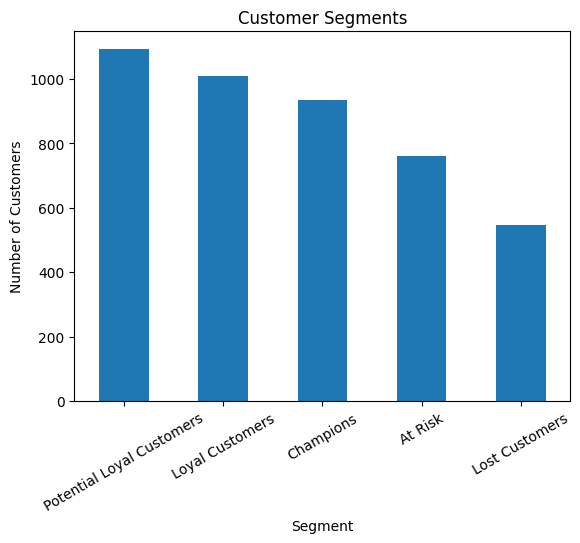

In [92]:
import matplotlib.pyplot as plt

customer_df["segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

In [93]:
segment_revenue = customer_df.groupby("segment")["total_spend"].sum().sort_values(ascending=False)

In [94]:
segment_revenue

segment
Champions                    6255336.530
Loyal Customers              1408629.911
Potential Loyal Customers     882612.662
At Risk                       259877.891
Lost Customers                104950.910
Name: total_spend, dtype: float64

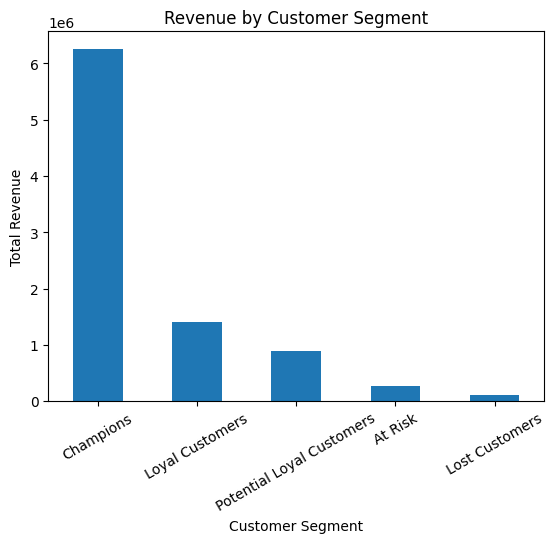

In [97]:
segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.show()

In [98]:
segment_revenue_pct = (
    segment_revenue / segment_revenue.sum() * 100
).round(2)

segment_revenue_pct

segment
Champions                    70.19
Loyal Customers              15.81
Potential Loyal Customers     9.90
At Risk                       2.92
Lost Customers                1.18
Name: total_spend, dtype: float64

In [99]:
segment_revenue_pct.sum()

np.float64(100.00000000000001)

In [100]:
features = [
    "total_spend",
    "number_of_orders",
    "average_order_value",
    "recency_days",
    "customer_lifetime_days",
    "purchase_frequency",
    "unique_products"
]

correlation = customer_df[features].corr()

correlation

,total_spend,number_of_orders,average_order_value,recency_days,customer_lifetime_days,purchase_frequency,unique_products
total_spend,1.000000,0.553650,0.393479,-0.122097,0.149501,0.221073,0.386977
number_of_orders,0.553650,1.000000,0.019063,-0.260578,0.313297,0.377154,0.692223
average_order_value,0.393479,0.019063,1.000000,-0.000276,0.009286,0.012796,0.036429
recency_days,-0.122097,-0.260578,-0.000276,1.000000,0.272267,-0.306108,-0.300728
customer_lifetime_days,0.149501,0.313297,0.009286,0.272267,1.000000,-0.250249,0.258615
purchase_frequency,0.221073,0.377154,0.012796,-0.306108,-0.250249,1.000000,0.267390
unique_products,0.386977,0.692223,0.036429,-0.300728,0.258615,0.267390,1.000000


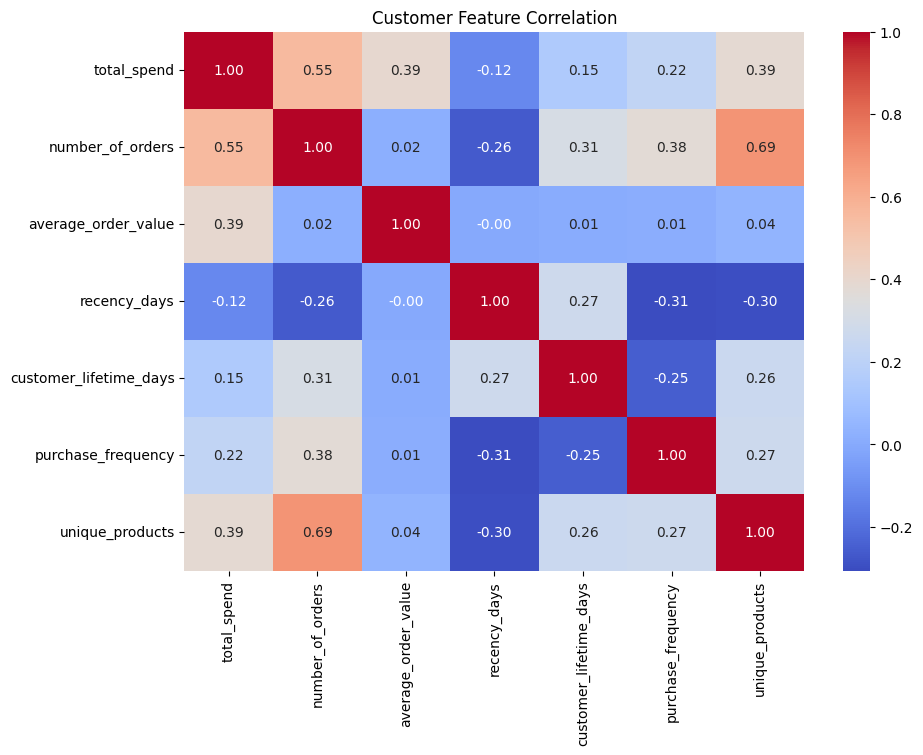

In [101]:
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Customer Feature Correlation")
plt.show()

In [102]:
from sklearn.preprocessing import StandardScaler

ml_features = [
    "total_spend",
    "number_of_orders",
    "average_order_value",
    "recency_days",
    "customer_lifetime_days",
    "purchase_frequency",
    "unique_products"
]

X = customer_df[ml_features].copy()

X.head()

,total_spend,number_of_orders,average_order_value,recency_days,customer_lifetime_days,purchase_frequency,unique_products
0,77183.60,1,77183.600000,325,325,0.003067,1
1,4310.00,7,615.714286,1,366,0.019074,103
2,1797.24,4,449.310000,74,357,0.011173,22
3,1757.55,1,1757.550000,18,18,0.052632,73
4,334.40,1,334.400000,309,309,0.003226,17


In [103]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 8.35866818e+00, -4.25096503e-01,  4.27340170e+01,
         2.33457414e+00,  8.71207962e-01, -4.72701511e-01,
        -7.08801901e-01],
       [ 2.50966264e-01,  3.54416797e-01,  1.09416367e-01,
        -9.05340320e-01,  1.21904030e+00, -1.33302139e-01,
         4.86180191e-01],
       [-2.85960063e-02, -3.53398530e-02,  1.67807118e-02,
        -1.75359593e-01,  1.14268686e+00, -3.00825039e-01,
        -4.62776177e-01],
       [-3.30117987e-02, -4.25096503e-01,  7.45065254e-01,
        -7.35344808e-01, -1.73329270e+00,  5.78275207e-01,
         1.34714870e-01],
       [-1.91347273e-01, -4.25096503e-01, -4.71885727e-02,
         2.17457836e+00,  7.35468514e-01, -4.69344393e-01,
        -5.21353730e-01]])

In [104]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

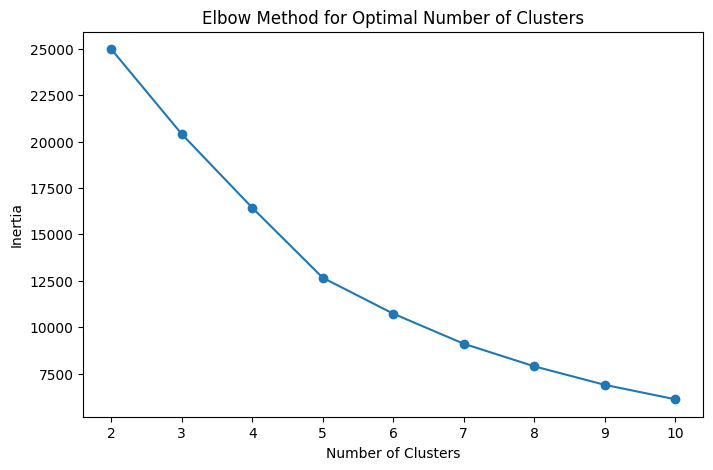

In [105]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.show()

In [106]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

customer_df["cluster"] = kmeans.fit_predict(X_scaled)

customer_df["cluster"].value_counts().sort_index()

cluster
0    1106
1    1554
2      16
3       2
4    1660
Name: count, dtype: int64

In [107]:
cluster_profile = customer_df.groupby("cluster")[ml_features].mean().round(2)

cluster_profile

,total_spend,number_of_orders,average_order_value,recency_days,customer_lifetime_days,purchase_frequency,unique_products
cluster,,,,,,,
0,586.83,1.65,338.33,242.29,278.10,0.01,24.53
1,691.35,1.95,369.96,46.62,85.61,0.04,37.16
2,105050.87,79.69,2101.19,6.00,350.31,0.22,743.62
3,122828.05,1.50,80709.92,162.50,265.00,0.01,2.00
4,3169.61,7.47,406.14,33.89,311.82,0.02,102.42


In [108]:
cluster_names = {
    0: "Lost Customers",
    1: "New / Low-Value Customers",
    2: "Champions",
    3: "High-Value Outliers",
    4: "Loyal Customers"
}

customer_df["customer_segment"] = customer_df["cluster"].map(cluster_names)

customer_df[["cluster", "customer_segment"]].head()

,cluster,customer_segment
0,3,High-Value Outliers
1,4,Loyal Customers
2,4,Loyal Customers
3,1,New / Low-Value Customers
4,0,Lost Customers


In [109]:
customer_df["customer_segment"].value_counts()

customer_segment
Loyal Customers              1660
New / Low-Value Customers    1554
Lost Customers               1106
Champions                      16
High-Value Outliers             2
Name: count, dtype: int64

In [110]:
segment_mapping = {
    0: "Lost Customers",
    1: "Potential Loyal Customers",
    2: "Champions",
    3: "At Risk",
    4: "Loyal Customers"
}

customer_df["segment"] = customer_df["cluster"].map(segment_mapping)

customer_df[["CustomerID", "cluster", "segment"]].head()

,CustomerID,cluster,segment
0,12346.0,3,At Risk
1,12347.0,4,Loyal Customers
2,12348.0,4,Loyal Customers
3,12349.0,1,Potential Loyal Customers
4,12350.0,0,Lost Customers


In [111]:
customer_df.to_csv("../data/customer_segments.csv", index=False)

In [112]:
segment_names = {
    0: "At Risk",
    1: "New Customers",
    2: "Champions",
    3: "High-Value Occasional",
    4: "Loyal Customers"
}

customer_df["segment"] = customer_df["cluster"].map(segment_names)

customer_df[["CustomerID", "cluster", "segment"]].head()

,CustomerID,cluster,segment
0,12346.0,3,High-Value Occasional
1,12347.0,4,Loyal Customers
2,12348.0,4,Loyal Customers
3,12349.0,1,New Customers
4,12350.0,0,At Risk


In [113]:
customer_df.to_csv("../data/customer_segments.csv", index=False)

In [114]:
pd.read_csv("../data/customer_segments.csv").head()

,CustomerID,total_spend,number_of_orders,average_order_value,recency_days,customer_lifetime_days,purchase_frequency,unique_products,R_score,F_score,M_score,RFM_score,segment,cluster,customer_segment
0,12346.0,77183.60,1,77183.600000,325,325,0.003067,1,1,1,5,7,High-Value Occasional,3,High-Value Outliers
1,12347.0,4310.00,7,615.714286,1,366,0.019074,103,5,5,5,15,Loyal Customers,4,Loyal Customers
2,12348.0,1797.24,4,449.310000,74,357,0.011173,22,2,4,4,10,Loyal Customers,4,Loyal Customers
3,12349.0,1757.55,1,1757.550000,18,18,0.052632,73,4,1,4,9,New Customers,1,New / Low-Value Customers
4,12350.0,334.40,1,334.400000,309,309,0.003226,17,1,1,2,4,At Risk,0,Lost Customers
